## Title : Design and implement Deep Convolutional GAN to generate images of faces/digits from a set of given images.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, BatchNormalization, LeakyReLU
from keras.datasets import fashion_mnist


## Load Dataset


In [3]:
(train_x, _), (_, _) = fashion_mnist.load_data()
train_x = train_x / 255.0
train_x = train_x.reshape(-1,28,28,1)
train_x = train_x * 2 - 1
print(train_x.shape)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 28, 28, 1)


## Generator


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU, BatchNormalization, Reshape, Input
generator = Sequential([
 Input(shape=(100,)), # ✅ correct way
 Dense(512),
 LeakyReLU(negative_slope=0.2),
 BatchNormalization(momentum=0.8), # ✅ FIXED
 Dense(256),
 LeakyReLU(negative_slope=0.2),
 BatchNormalization(momentum=0.8),
 Dense(128),
 LeakyReLU(negative_slope=0.2),
 BatchNormalization(momentum=0.8),
 Dense(784, activation='tanh'), # GAN standard
 Reshape((28, 28, 1))
])
generator.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 512)                 │          51,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu (LeakyReLU)              │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_1 (LeakyReLU)            │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_2 (LeakyReLU)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 784)                 │         101,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 28, 28, 1)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 320,656 (1.22 MB)

 Trainable params: 318,864 (1.22 MB)

 Non-trainable params: 1,792 (7.00 KB)

## Discriminator

In [7]:
discriminator = Sequential([
Flatten(input_shape=(28,28,1)),
Dense(256),
LeakyReLU(0.2),
Dropout(0.5),
Dense(128),
LeakyReLU(0.2),
Dropout(0.5),
Dense(64),
LeakyReLU(0.2),
Dropout(0.5),
Dense(1, activation='sigmoid')
])
discriminator.compile(optimizer='adam', loss='binary_crossentropy')
discriminator.summary()


C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_3 (LeakyReLU)            │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_4 (LeakyReLU)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_5 (LeakyReLU)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 242,177 (946.00 KB)

 Trainable params: 242,177 (946.00 KB)

 Non-trainable params: 0 (0.00 B)

## GAN Model


In [8]:
discriminator.trainable = False
gan = Sequential([generator, discriminator])
gan.compile(optimizer='adam', loss='binary_crossentropy')
gan.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 28, 28, 1)           │         320,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_1 (Sequential)            │ (None, 1)                   │         242,177 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 562,833 (2.15 MB)

 Trainable params: 318,864 (1.22 MB)

 Non-trainable params: 243,969 (953.00 KB)

## Training

Epoch 1


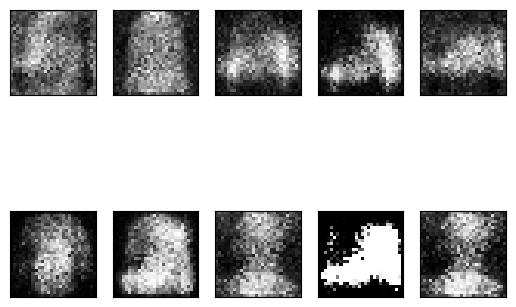

Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Training complete


In [14]:
epochs = 10
batch_size = 100
noise_dim = 100 

for epoch in range(epochs):
    print(f"Epoch {epoch+1}")
    
    # 1. Indent the batch loop to run inside EACH epoch
    for i in range(train_x.shape[0] // batch_size):
        noise = np.random.normal(0, 1, (batch_size, noise_dim))
        fake = generator.predict(noise, verbose=0)
        real = train_x[i * batch_size : (i+1) * batch_size]
        
        y_real = np.ones((batch_size, 1))
        y_fake = np.zeros((batch_size, 1))
        
        discriminator.trainable = True
        discriminator.train_on_batch(real, y_real)
        discriminator.train_on_batch(fake, y_fake)
        
        noise = np.random.normal(0, 1, (batch_size, noise_dim))
        discriminator.trainable = False
        gan.train_on_batch(noise, y_real)
        
    # 2. Indent the plotting block to check conditions during EACH epoch
    if epoch % 10 == 0:
        samples = 10
        gen = generator.predict(np.random.normal(0, 1, (samples, noise_dim)), verbose=0)
        for k in range(samples):
            plt.subplot(2, 5, k+1)
            plt.imshow(gen[k].reshape(28, 28), cmap='gray')
            plt.xticks([])
            plt.yticks([])
        plt.show()

print('Training complete')


## Final Output


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


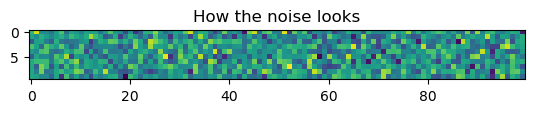

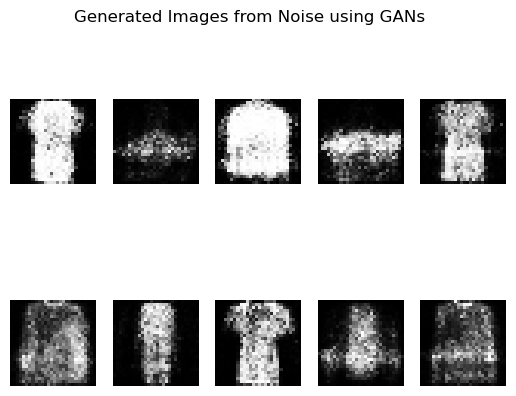

In [18]:
noise = np.random.normal(0,1,(10,100))
gen = generator.predict(noise)

plt.imshow(noise)
plt.title('How the noise looks')
plt.show()

fig, ax = plt.subplots(2,5)
fig.suptitle('Generated Images from Noise using GANs')
idx=0
for i in range(2):
 for j in range(5):
  ax[i,j].imshow(gen[idx].reshape(28,28), cmap='gray')
  ax[i,j].axis('off')
  idx+=1
plt.show()
